In [1]:
import pandas as pd
pd.options.display.max_columns = None
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier, Perceptron, SGDClassifier, RidgeClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, cross_val_score, train_test_split, HalvingGridSearchCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score

### Preprocessing

In [3]:
df = pd.read_csv('fraudTrain.csv', index_col=0, parse_dates=['trans_date_trans_time'])

Based on discoveries of EDA, I delete some featurs and transform others.

In [5]:
df.rename(columns={'trans_date_trans_time':'time', 'amt':'amount'}, inplace=True)
#df['day'] = df['time'].dt.day
#df['weekday'] = df['time'].dt.weekday
#df['hour'] = df['time'].dt.hour
df['industry_code'] = df['cc_num'].astype(str).apply(lambda x: x[0:1]).astype(int)
df['age'] = (pd.to_datetime('today') - pd.to_datetime(df['dob'])).dt.days/365.25 
df.drop(columns=['time', 'first', 'last', 'street', 'trans_num', 'unix_time', 'cc_num', 'dob', 'lat', 'long', 'merch_lat', 'merch_long', 'zip', 'city', 'job', 'merchant'], inplace=True)

### Feature generation

In [10]:
y = df['is_fraud']
df.drop(columns='is_fraud', inplace=True)

str_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include='number').columns
'''
df_num = df.drop(columns=str_cols)
df_cat = df[str_cols]

del df
'''

'\ndf_num = df.drop(columns=str_cols)\ndf_cat = df[str_cols]\n\ndel df\n'

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first', sparse_output=False, dtype=bool), str_cols),
        ('transformer', PolynomialFeatures(degree=3, include_bias=False), num_cols),
    ],
    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')

df = preprocessor.fit_transform(df)
df.head()

,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,amount,city_pop,industry_code,age,amount^2,amount city_pop,amount industry_code,amount age,city_pop^2,city_pop industry_code,city_pop age,industry_code^2,industry_code age,age^2,amount^3,amount^2 city_pop,amount^2 industry_code,amount^2 age,amount city_pop^2,amount city_pop industry_code,amount city_pop age,amount industry_code^2,amount industry_code age,amount age^2,city_pop^3,city_pop^2 industry_code,city_pop^2 age,city_pop industry_code^2,city_pop industry_code age,city_pop age^2,industry_code^3,industry_code^2 age,industry_code age^2,age^3
0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,4.97,3495.0,2.0,36.668036,24.7009,17370.15,9.94,182.240137,12215025.0,6990.0,128154.784394,4.0,73.336071,1344.544834,1.227635e+02,8.632965e+04,49.4018,9.057335e+02,6.070867e+07,34740.30,6.369293e+05,19.88,364.480274,6682.387826,4.269151e+10,24430050.0,4.479010e+08,13980.0,256309.568789,4.699184e+06,8.0,146.672142,2689.089668,49301.817835
1,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,107.23,149.0,6.0,46.384668,11498.2729,15977.27,643.38,4973.827953,22201.0,894.0,6911.315537,36.0,278.308008,2151.537429,1.232960e+06,1.713243e+06,68989.6374,5.333436e+05,2.380613e+06,95863.62,7.411004e+05,3860.28,29842.967721,230709.358487,3.307949e+06,133206.0,1.029786e+06,5364.0,41467.893224,3.205791e+05,216.0,1669.848049,12909.224573,99798.349400
2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,220.11,4154.0,3.0,62.803559,48448.4121,914336.94,660.33,13823.691417,17255716.0,12462.0,260885.984942,9.0,188.410678,3944.287049,1.066398e+07,2.012547e+08,145345.2363,3.042733e+06,3.798156e+09,2743010.82,5.742361e+07,1980.99,41471.074251,868177.022343,7.168024e+10,51767148.0,1.083720e+09,37386.0,782657.954825,1.638457e+07,27.0,565.232033,11832.861147,247715.265204
3,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,45.00,1939.0,3.0,57.823409,2025.0000,87255.00,135.00,2602.053388,3759721.0,5817.0,112119.589322,9.0,173.470226,3343.546585,9.112500e+0

In [ ]:
#df = pd.concat([df_num, df_cat], axis=1)
#del df_num, df_cat

In [135]:
def evaluate(X, y):
    models = dict()
    
    models['Logistic Regression'] = LogisticRegression(random_state=1, max_iter=100000, class_weight='balanced')    
    #models['SVC'] = SVC(class_weight='balanced', random_state=1)
    models['SGD'] = SGDClassifier(random_state=1, class_weight='balanced')
    '''
    models['Nearest Neighbor'] = KNeighborsClassifier(3)
    models['Naive Bayes'] = GaussianNB()
    models['Decision Tree'] = DecisionTreeClassifier(random_state=1, class_weight='balanced')
    models['Random Forest'] = RandomForestClassifier(random_state=1, class_weight='balanced')
    models['MLPC'] = MLPClassifier(random_state=1)'''

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=1)#(n_splits=5, n_repeats=10, random_state=1)
    
    res = pd.DataFrame()

    for name, model in models.items():
        print('         ', name)
        scores = cross_val_score(model, X, y, scoring='f1_weighted', cv=cv, n_jobs=3)
        print('Min:', min(scores), 'Max:', max(scores), 'Mean:', np.mean(scores))
        res[name] = scores

    plt.figure(figsize=(10, 8))
    sns.boxplot(data=res)
    
    for i in range(res.shape[1]):    
        plt.text(i - 0.4, res.iloc[:, i].max() + 0.0005, 'Mean: ' + str(res.iloc[:, i].mean())[:6], fontsize=8)
        
    plt.grid()

### Feature selection

In [14]:
bool_cols = df.select_dtypes(include='bool').columns
num_cols = df.select_dtypes(include='number').columns

In [24]:
scaler = ColumnTransformer(
    transformers=[('scaler', StandardScaler(), num_cols)],
                    remainder='passthrough', verbose_feature_names_out=False).set_output(transform='pandas')
        
df = scaler.fit_transform(df)
df.head()

,amount,city_pop,industry_code,age,amount^2,amount city_pop,amount industry_code,amount age,city_pop^2,city_pop industry_code,city_pop age,industry_code^2,industry_code age,age^2,amount^3,amount^2 city_pop,amount^2 industry_code,amount^2 age,amount city_pop^2,amount city_pop industry_code,amount city_pop age,amount industry_code^2,amount industry_code age,amount age^2,city_pop^3,city_pop^2 industry_code,city_pop^2 age,city_pop industry_code^2,city_pop industry_code age,city_pop age^2,industry_code^3,industry_code^2 age,industry_code age^2,age^3,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M,state_AL,state_AR,state_AZ,state_CA,state_CO,state_CT,state_DC,state_DE,state_FL,state_GA,state_HI,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_MT,state_NC,state_ND,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY
0,-0.407826,-0.282589,-1.351318,-0.829704,-0.017526,-0.112019,-0.374022,-0.377983,-0.159244,-0.265850,-0.290928,-1.113596,-1.239340,-0.786088,-0.004363,-0.007477,-0.014130,-0.014365,-0.068348,-0.115129,-0.118048,-0.316070,-0.342192,-0.317775,-0.11199,-0.140257,-0.166542,-0.235479,-0.262940,-0.277928,-0.893107,-1.060484,-0.944811,-0.701891,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,0.230039,-0.293670,1.960079,-0.270974,-0.010960,-0.112043,0.592132,0.157015,-0.159264,-0.271054,-0.299915,2.231503,1.020136,-0.381723,-0.004333,-0.007473,-0.005799,-0.009570,-0.068349,-0.114831,-0.118007,0.886221,0.459000,0.047812,-0.11199,-0.140266,-0.166560,-0.237073,-0.266798,-0.284064,2.392857,1.617592,0.276209,-0.436769,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,0.934149,-0.280406,-0.523469,0.673150,0.010185,-0.096593,0.617985,1.145134,-0.159236,-0.261178,-0.281088,-0.590924,0.029167,0.516581,-0.004105,-0.006978,0.003428,0.013030,-0.068314,-0.101937,-0.095808,0.297883,0.775039,1.088087,-0.11199,-0.140246,-0.166517,-0.231148,-0.253488,-0.261555,-0.592947,-0.324564,0.147614,0.339840,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,-0.158132,-0.287742,-0.523469,0.386780,-0.016382,-0.110817,-0.183275,-0.107802,-0.159258,-0.266851,-0.292116,-0.590924,-0.135527,0.215564,-0.004361,-0.007467,-0.013402,-0.013319,-0.068347,-0.114023,-0.116321,-0.195502,-0.139936,-0.083147,-0.11199,-0.140262,-0.166551,-0.234837,-0.261502,-0.275429,-0.592947,-0.403370,-0.067701,0.054328,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,Fals

In [26]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.25, random_state=1)

In [28]:
X_train_num = X_train[num_cols]
X_train_bool = X_train[bool_cols]

In [16]:
pca = PCA(n_components=0.99, copy=False)
pca.fit
X_train_num = pd.DataFrame(pca.fit_transform(X_train_num))
print(X_train_num.shape)
X_train_num.info()

(972506, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 972506 entries, 0 to 972505
Data columns (total 18 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       972506 non-null  float64
 1   1       972506 non-null  float64
 2   2       972506 non-null  float64
 3   3       972506 non-null  float64
 4   4       972506 non-null  float64
 5   5       972506 non-null  float64
 6   6       972506 non-null  float64
 7   7       972506 non-null  float64
 8   8       972506 non-null  float64
 9   9       972506 non-null  float64
 10  10      972506 non-null  float64
 11  11      972506 non-null  float64
 12  12      972506 non-null  float64
 13  13      972506 non-null  float64
 14  14      972506 non-null  float64
 15  15      972506 non-null  float64
 16  16      972506 non-null  float64
 17  17      972506 non-null  float64
dtypes: float64(18)
memory usage: 133.6 MB


In [15]:
X_train = pd.concat([X_train_num, X_train_cat], axis=1)

          Logistic Regression
Min: 0.9332083851112444 Max: 0.9380888672807804 Mean: 0.9352638463761453
          SGD
Min: 0.9315383211348768 Max: 0.9685843405417073 Mean: 0.9566142615053312


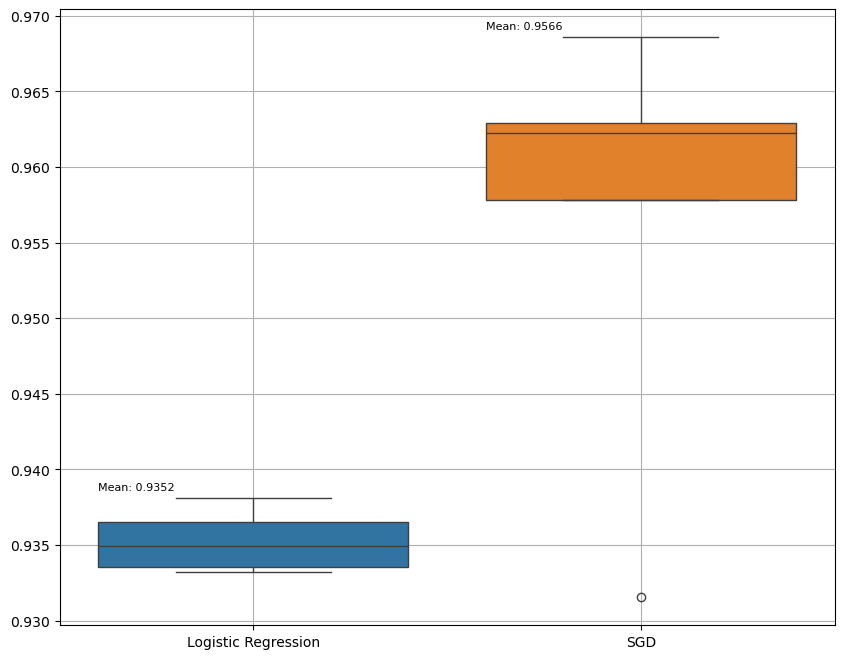

In [ ]:
evaluate(X_train, y_train)

### Handling imbalanced data

In [ ]:
    models = dict()
    
    models['Logistic Regression'] = LogisticRegression(random_state=1, max_iter=100000, class_weight='balanced')    
    #models['SVC'] = SVC(class_weight='balanced', random_state=1)
    models['SGD'] = SGDClassifier(random_state=1, class_weight='balanced')
    '''
    models['Nearest Neighbor'] = KNeighborsClassifier(3)
    models['Naive Bayes'] = GaussianNB()
    models['Decision Tree'] = DecisionTreeClassifier(random_state=1, class_weight='balanced')
    models['Random Forest'] = RandomForestClassifier(random_state=1, class_weight='balanced')
    models['MLPC'] = MLPClassifier(random_state=1)'''

    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=1)#(n_splits=5, n_repeats=10, random_state=1)
    
    res = pd.DataFrame()

    for name, model in models.items():
        print('         ', name)
        gs = GridSearchCV(model, cv=2)
        gs.fit(X_train, y_train)
        res[name] = f1_score(y_test, gs.best_estimator_.predict(X_test), average='weighted')
        

In [ ]:
models = dict()

models['Logistic Regression'] = LogisticRegression(random_state=1, max_iter=100000, class_weight='balanced')    
#models['SVC'] = SVC(class_weight='balanced', random_state=1)
models['SGD'] = SGDClassifier(random_state=1, class_weight='balanced')
'''
models['Nearest Neighbor'] = KNeighborsClassifier(3)
models['Naive Bayes'] = GaussianNB()
models['Decision Tree'] = DecisionTreeClassifier(random_state=1, class_weight='balanced')
models['Random Forest'] = RandomForestClassifier(random_state=1, class_weight='balanced')
models['MLPC'] = MLPClassifier(random_state=1)'''

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=1)#(n_splits=5, n_repeats=10, random_state=1)

names, res = [], []

for name, model in models.items():
    print('         ', name)
    scores = cross_val_score(model, X_train, y_train, scoring='f1_weighted', cv=cv, n_jobs=3)#scoring='accuracy'
    print('Min:', min(scores), 'Max:', max(scores), 'Mean:', np.mean(scores))
    res.append(scores)
    names.append(name)



          Logistic Regression
Min: 0.9332083851112444 Max: 0.9380888672807804 Mean: 0.9352638463761453
          SGD
Min: 0.9315383211348768 Max: 0.9685843405417073 Mean: 0.9566142615053312
